In [ ]:

import torch
import torch.nn as nn
from torch.utils.data import DataLoader
from torchvision import datasets, transforms
import matplotlib.pyplot as plt
import numpy as np

torch.manual_seed(42)
np.random.seed(42)

device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
print("Device:", device)

Device: cuda


In [2]:
batch_size = 128
epochs = 10
lr = 0.01
n_visible = 784
n_hidden = 128

In [3]:
transform = transforms.ToTensor()

train_ds = datasets.MNIST("./data", train=True, download=True, transform=transform)
test_ds  = datasets.MNIST("./data", train=False, download=True, transform=transform)

train_loader = DataLoader(train_ds, batch_size=batch_size, shuffle=True)
test_loader  = DataLoader(test_ds, batch_size=batch_size)

100%|██████████| 9.91M/9.91M [00:02<00:00, 4.42MB/s]
100%|██████████| 28.9k/28.9k [00:00<00:00, 115kB/s]
100%|██████████| 1.65M/1.65M [00:01<00:00, 1.10MB/s]
100%|██████████| 4.54k/4.54k [00:00<00:00, 4.54MB/s]


In [4]:
class RBM(nn.Module):
    def __init__(self, n_visible, n_hidden):
        super().__init__()
        self.W = nn.Parameter(torch.randn(n_visible, n_hidden) * 0.01)
        self.v_bias = nn.Parameter(torch.zeros(n_visible))
        self.h_bias = nn.Parameter(torch.zeros(n_hidden))

    def sample(self, p):
        return torch.bernoulli(p)

    def v_to_h(self, v):
        p = torch.sigmoid(v @ self.W + self.h_bias)
        return p, self.sample(p)

    def h_to_v(self, h):
        p = torch.sigmoid(h @ self.W.t() + self.v_bias)
        return p, self.sample(p)

    def reconstruct(self, v):
        h, _ = self.v_to_h(v)
        v, _ = self.h_to_v(h)
        return v


In [5]:
rbm = RBM(n_visible, n_hidden).to(device)

In [6]:
recon_errors = []

for epoch in range(epochs):
    total_err = 0

    for x, _ in train_loader:
        v0 = x.view(-1, 784).to(device)

        ph0, h0 = rbm.v_to_h(v0)
        vk_prob, vk = rbm.h_to_v(h0)
        phk, _ = rbm.v_to_h(vk)

        with torch.no_grad():
            bs = v0.size(0)
            rbm.W += lr * ((v0.t() @ ph0) - (vk.t() @ phk)) / bs
            rbm.v_bias += lr * torch.mean(v0 - vk, dim=0)
            rbm.h_bias += lr * torch.mean(ph0 - phk, dim=0)

        total_err += torch.mean((v0 - vk_prob) ** 2).item() * bs

    err = total_err / len(train_loader.dataset)
    recon_errors.append(err)
    print(f"Epoch {epoch+1}: Recon Error = {err:.6f}")

Epoch 1: Recon Error = 0.071519
Epoch 2: Recon Error = 0.049147
Epoch 3: Recon Error = 0.042240
Epoch 4: Recon Error = 0.038532
Epoch 5: Recon Error = 0.035754
Epoch 6: Recon Error = 0.033689
Epoch 7: Recon Error = 0.031976
Epoch 8: Recon Error = 0.030514
Epoch 9: Recon Error = 0.029299
Epoch 10: Recon Error = 0.028282


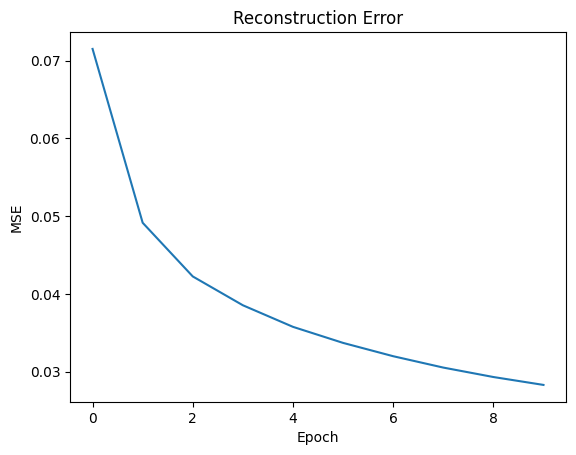

In [7]:
plt.plot(recon_errors)
plt.title("Reconstruction Error")
plt.xlabel("Epoch")
plt.ylabel("MSE")
plt.show()

In [8]:
rbm.eval()
test_err = 0

with torch.no_grad():
    for x, _ in test_loader:
        v = x.view(-1, 784).to(device)
        recon = rbm.reconstruct(v)
        test_err += torch.mean((v - recon) ** 2).item() * v.size(0)

print("Test Recon Error:", test_err / len(test_loader.dataset))

Test Recon Error: 0.025253055852651595


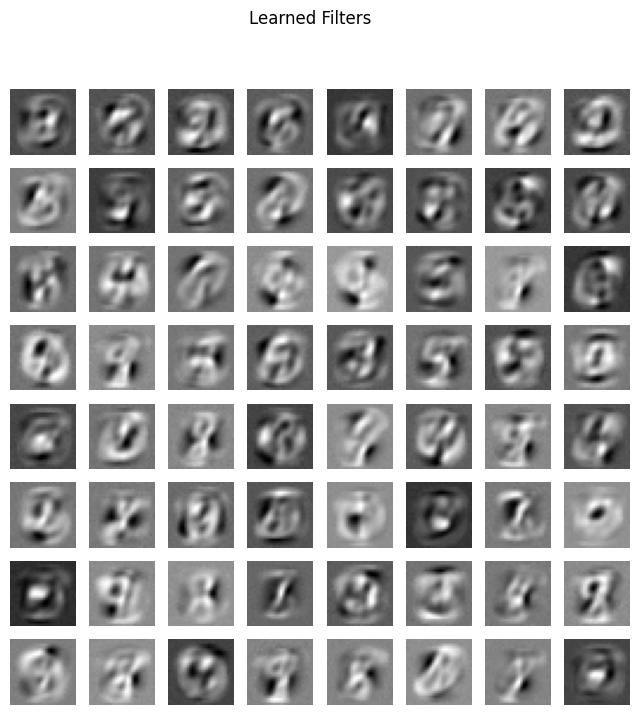

In [9]:
W = rbm.W.detach().cpu().T

plt.figure(figsize=(8,8))
for i in range(64):
    plt.subplot(8,8,i+1)
    plt.imshow(W[i].view(28,28), cmap="gray")
    plt.axis("off")
plt.suptitle("Learned Filters")
plt.show()